# Exploració de dades — TCGA-COAD RNA-seq

Aquest notebook explora les dades d'expressió gènica **després del preprocessament** (etapa 2).
L'objectiu és entendre la qualitat i l'estructura de les dades **abans** d'entrenar cap model.

Explorar les dades primer és una bona pràctica: permet detectar problemes, verificar que el
preprocessament ha funcionat correctament i tenir intuïció sobre si els subtipus CMS
es poden separar a partir de l'expressió gènica.

---

## Contingut

1. [Càrrega de dades](#1-càrrega-de-dades)
2. [Descripció del dataset](#2-descripció-del-dataset)
3. [Distribució de les classes CMS](#3-distribució-de-les-classes-cms)
4. [Distribució dels valors d'expressió](#4-distribució-dels-valors-dexpressió)
5. [PCA — Reducció a 2 dimensions](#5-pca--reducció-a-2-dimensions)
6. [Quanta variança explica cada component?](#6-quanta-variança-explica-cada-component)
7. [Quins gens contribueixen més a la separació?](#7-quins-gens-contribueixen-més-a-la-separació)
8. [UMAP — Visualització no lineal](#8-umap--visualització-no-lineal)
9. [Conclusions](#9-conclusions)

## 0. Imports i configuració

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.dimensionality_reduction import (
    apply_pca,
    fit_pca,
    plot_explained_variance,
    plot_pca_scatter,
    plot_top_genes,
    plot_umap_scatter,
    CMS_PALETTE,
)

# Directoris del projecte
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Estil global dels gràfics
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("Imports OK")

Imports OK


## 1. Càrrega de dades

Carguem els fitxers generats per `scripts/preprocess.py`.

Recordem l'estructura de sortida del preprocessament:

| Fitxer | Contingut |
|--------|----------|
| `X_train.csv` | Matriu d'expressió — mostres com a files, gens com a columnes |
| `X_test.csv` | Idem per al conjunt de test |
| `y_train.csv` | Etiqueta CMS per cada mostra de train |
| `y_test.csv` | Idem per a test |
| `gene_names.csv` | Mapatge `gene_id` → `gene_name` (nom llegible) |
| `preprocessing_log.json` | Paràmetres i comptadors del preprocessament |

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv", index_col=0)
X_test  = pd.read_csv(PROCESSED_DIR / "X_test.csv",  index_col=0)
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv", index_col=0).squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / "y_test.csv",  index_col=0).squeeze()
gene_names = pd.read_csv(PROCESSED_DIR / "gene_names.csv")

print(f"X_train: {X_train.shape}  →  {X_train.shape[0]} mostres, {X_train.shape[1]} gens")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"gene_names: {gene_names.shape}")

X_train: (296, 15625)  →  296 mostres, 15625 gens
X_test:  (74, 15625)
y_train: (296,)
y_test:  (74,)
gene_names: (15625, 2)


## 2. Descripció del dataset

Inspeccionem les primeres files i columnes per verificar que la càrrega és correcta.

In [3]:
# Primeres 5 mostres, primers 6 gens
# Els valors son log2(comptatge + 1) — rang esperat: [0, ~21]
X_train.iloc[:5, :6]

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13
TCGA-CK-5912,13.603858,5.357552,11.967947,9.533330,9.368506,7.011227
TCGA-AA-3854,11.140830,1.584963,9.453271,8.985842,8.266787,6.554589
TCGA-AD-6964,11.819780,5.321928,10.043027,8.864186,7.139551,9.087463
TCGA-CM-6167,11.641149,5.000000,11.301496,9.461479,8.348728,8.813781
TCGA-AA-3968,12.575776,5.087463,11.149747,8.299208,8.738092,6.807355


In [4]:
# Estadístiques bàsiques globals
print(f"Valor mínim:  {X_train.min().min():.2f}")
print(f"Valor màxim:  {X_train.max().max():.2f}")
print(f"Mitjana:      {X_train.mean().mean():.2f}")
print(f"Desv. típica: {X_train.std().mean():.2f}")

Valor mínim:  0.00
Valor màxim:  20.71
Mitjana:      8.51
Desv. típica: 1.27


## 3. Distribució de les classes CMS

Volem saber si les 4 classes estan equilibrades. Un **desbalanceig** pot afectar
el rendiment dels models: si CMS3 té molt poques mostres, el model pot aprendre
a ignorar-la i obtenir igualment un accuracy alt.

El dataset TCGA-COAD ja és conegut per tenir CMS2 dominant (~39%) i CMS3 minoritari (~15%).

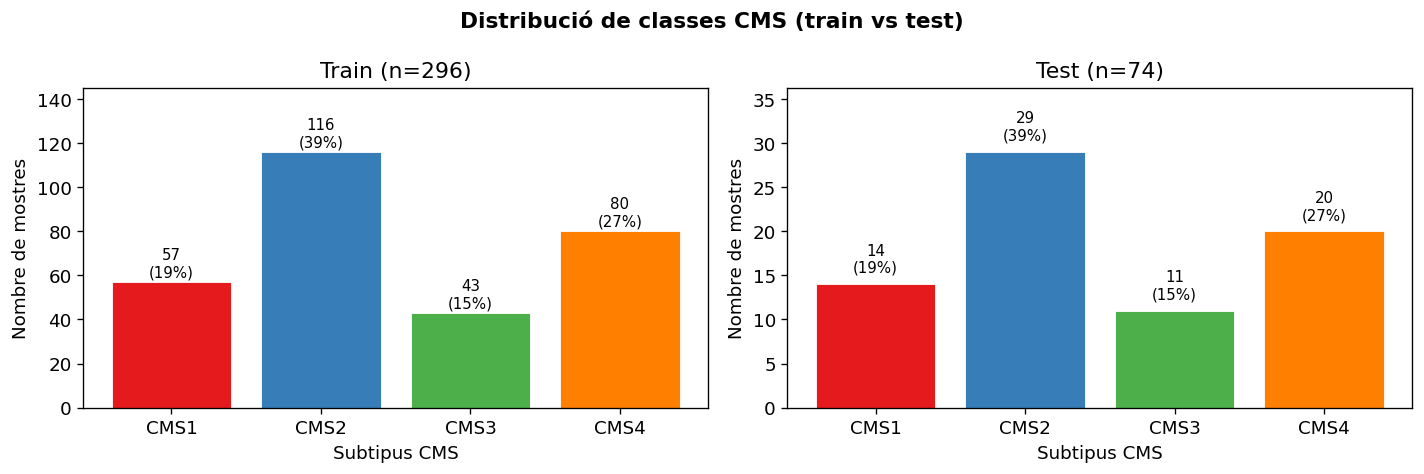

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (y, title) in zip(axes, [(y_train, "Train (n=296)"), (y_test, "Test (n=74)")]):
    counts = y.value_counts().sort_index()
    colours = [CMS_PALETTE[c] for c in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colours, edgecolor="white", linewidth=0.5)

    # Afegir percentatge sobre cada barra
    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{count}\n({count/total*100:.0f}%)",
            ha="center", va="bottom", fontsize=9
        )

    ax.set_title(title)
    ax.set_xlabel("Subtipus CMS")
    ax.set_ylabel("Nombre de mostres")
    ax.set_ylim(0, counts.max() * 1.25)

fig.suptitle("Distribució de classes CMS (train vs test)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cms_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Observació:** Les proporcions de train i test haurien de ser similars (split estratificat).
Si CMS3 és molt minoritari, caldrà tenir-ho en compte a l'hora d'avaluar els models
(no usar accuracy com a única mètrica).

## 4. Distribució dels valors d'expressió

### Què estem inspeccionant i per què?

Cada mostra conté 15.625 valors numèrics (un per gen), tots en escala log2(x+1).
Volem comprovar dues coses:

**a) Que la transformació log2 ha funcionat correctament**

En dades RNA-seq sense filtrar, la distribució és bimodal (dos pics): molts gens
apagats prop de 0 i gens actius a valors més alts. Però nosaltres al pas 7 del
preprocessament **vam eliminar tots els gens amb baixa expressió** (comptatge < 10
en menys del 20% de les mostres). Això vol dir que els gens que formarien el pic
de "0" ja no existeixen al nostre dataset.

Per tant, el que esperem veure amb les nostres dades filtrades és una distribució
**unimodal** (un sol pic) al voltant de **8-10 log2** — tots els gens que queden
s'expressen a nivells moderats o alts. Això és el comportament correcte.

**b) Que totes les mostres tenen un perfil similar (no hi ha outliers)**

Representem la **mitjana d'expressió per mostra** separada per subtipus CMS.
Totes les mostres haurien de tenir una mitjana similar (±1-2 unitats log2).

Per a nosaltres com a informàtics: és equivalent a verificar que tots els registres
d'una base de dades estan en el mateix rang de valors. Si una fila tingués valors
molt fora del rang normal, sospitaríem d'un error de dades.

### Tipus de gràfics

**Histograma (esquerra):** l'eix X és el valor log2, l'eix Y el nombre de valors en aquell rang.
Permet veure la forma global de la distribució de tots els valors del dataset.

**Boxplot per CMS (dreta):** per a cada subtipus, mostra la distribució de les
mitjanes per mostra.

Anatomia d'un boxplot:
```
         ┌───────┐
  ───────┤       ├────────  ← bigotis (fins a 1.5×IQR des de la caixa)
         │   ─   │          ← mediana (línia central)
         └───────┘
    ○               ○       ← outliers (punts fora dels bigotis)
```
- **Caixa:** conté el 50% central de les mostres (de Q1 a Q3)
- **Línia central:** mediana (la mostra exactament al mig)
- **Bigotis:** s'extenen fins a 1.5 vegades l'amplada de la caixa
- **Punts ○:** mostres individuals que queden fora dels bigotis — s'anomenen **outliers**
  i no indiquen necessàriament un problema, sinó simplement que aquelles mostres
  concretes tenen una mitjana d'expressió força diferent de la resta del seu subtipus


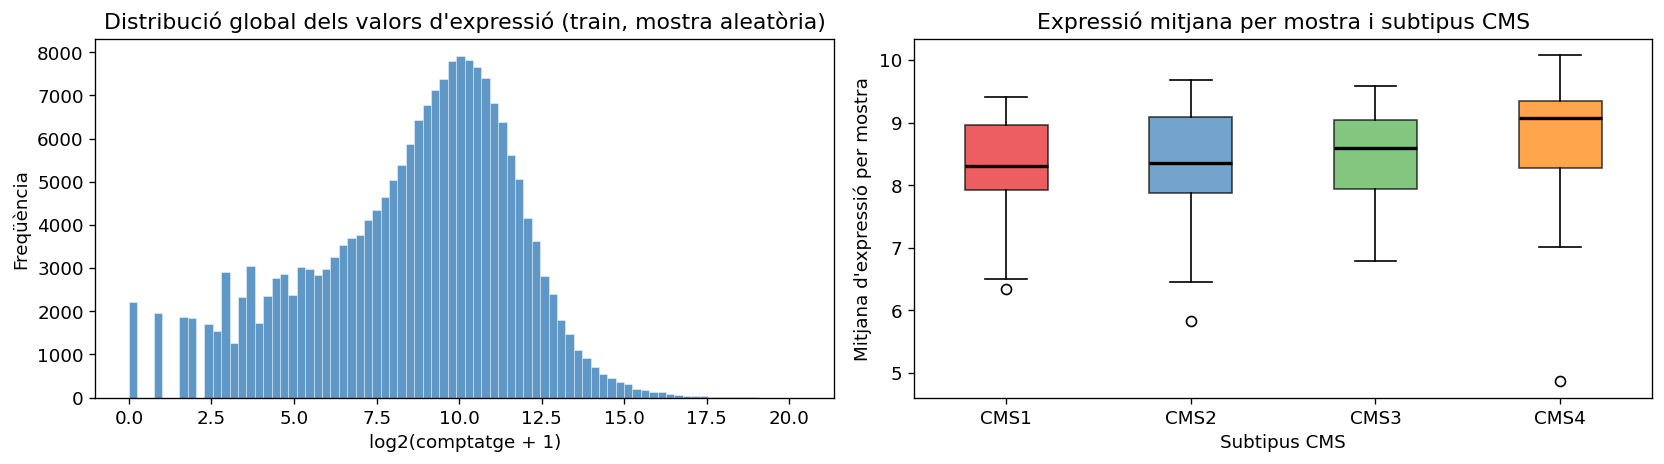

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Distribució global de tots els valors ---
ax = axes[0]
flat_values = X_train.values.flatten()
# Mostrem una mostra aleatòria per rapidesa (tot el dataset serien ~4.6M valors)
rng = np.random.default_rng(42)
sample_vals = rng.choice(flat_values, size=200_000, replace=False)
ax.hist(sample_vals, bins=80, color="#377EB8", alpha=0.8, edgecolor="white", linewidth=0.3)
ax.set_xlabel("log2(comptatge + 1)")
ax.set_ylabel("Freqüència")
ax.set_title("Distribució global dels valors d'expressió (train, mostra aleatòria)")

# --- Mitjana per mostra (boxplot per CMS) ---
ax = axes[1]
data_by_cms = {
    cms: X_train.loc[y_train == cms].mean(axis=1).values
    for cms in ["CMS1", "CMS2", "CMS3", "CMS4"]
}
bp = ax.boxplot(
    list(data_by_cms.values()),
    tick_labels=list(data_by_cms.keys()),
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
)
for patch, colour in zip(bp["boxes"], CMS_PALETTE.values()):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
ax.set_xlabel("Subtipus CMS")
ax.set_ylabel("Mitjana d'expressió per mostra")
ax.set_title("Expressió mitjana per mostra i subtipus CMS")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "expression_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretació dels resultats:**
- **Histograma:** un sol pic al voltant de 8-10 log2 és el comportament correcte
  per a les nostres dades — confirma que el filtratge de gens ha funcionat bé.
- **Boxplot:** les 4 caixes alineades a la mateixa alçada indiquen que no hi ha
  biaix tècnic entre subtipus. Els punts ○ outliers són mostres individuals atípiques;
  si n'hi ha pocs i no formen un patró, no cal preocupar-se.


## 5. PCA — Reducció a 2 dimensions

### Analogia per a informàtics

Imagina que tens una taula amb 296 files (mostres) i 15.625 columnes (gens).
Vols fer un scatter plot per veure si les mostres CMS1-4 formen grups,
però un scatter plot només pot representar 2 eixos.

PCA resol aquest problema: **comprimeix les 15.625 columnes en 2** (o les que vulguis),
conservant la màxima informació possible.

Com ho fa? Troba les dues "direccions" de l'espai de 15.625 dimensions on les dades
**varien més**. La primera direcció (PC1) captura la màxima variança; la segona (PC2)
captura la màxima variança perpendicular a PC1; etc.

### Com s'aplica en aquest projecte

```
X_train (296 mostres × 15.625 gens)
        │
        ▼  pca.fit(X_train)  ← aprèn les direccions principals del TRAIN
        │
        ▼  pca.transform(X_train)  ← projecta el train
pca_train (296 mostres × 50 components)

X_test  (74 mostres × 15.625 gens)
        │
        ▼  pca.transform(X_test)   ← usa les MATEIXES direccions del train
pca_test  (74 mostres × 50 components)
```

**Per què fit només sobre train?** Si fitegem PCA sobre totes les dades (train + test),
les "direccions principals" es calcularien tenint en compte el test, i el model
rebria informació indirecta d'ell durant l'entrenament → data leakage.
És el mateix principi que amb el filtratge de gens de l'etapa 2.

### Tipus de gràfic: scatter plot

Un **scatter plot** representa cada mostra com un punt en 2D:
- Eix X = valor de PC1 per a aquella mostra
- Eix Y = valor de PC2 per a aquella mostra
- Color = subtipus CMS de la mostra

**Què hauríem de veure:**
Si els 4 subtipus formen **grups separats** (punts del mateix color agrupats junts),
significa que l'expressió gènica diferencia bé els CMS → bon senyal per als models.
Si els grups **se superposen molt**, la classificació serà difícil.

> **Nota:** PC1 i PC2 normalment capturen un 10-30% de la variança total en dades RNA-seq.
> Que els grups no se seperin perfectament en 2D **no implica** que el problema sigui
> insoluble — els models entrenen amb 15.625 dimensions, no amb 2.


In [7]:
# Ajustar PCA sobre les dades d'entrenament
pca = fit_pca(X_train, n_components=50)

# Projectar train i test
pca_train = apply_pca(pca, X_train)
pca_test  = apply_pca(pca, X_test)

print(f"PCA ajustat: {pca.n_components_} components")
print(f"Variança explicada pels 2 primers components: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")
print(f"Variança explicada pels 10 primers components: {pca.explained_variance_ratio_[:10].sum()*100:.1f}%")

PCA ajustat: 50 components
Variança explicada pels 2 primers components: 46.4%
Variança explicada pels 10 primers components: 64.7%


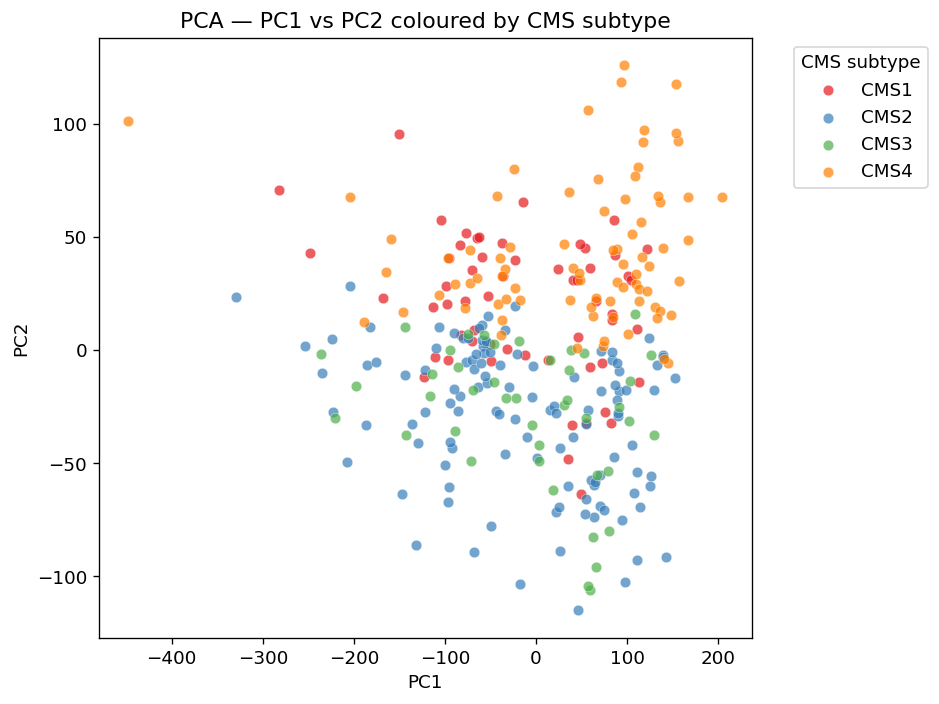

In [8]:
# Scatter PC1 vs PC2 — dades de train
fig = plot_pca_scatter(
    pca_train, y_train,
    pc_x=1, pc_y=2,
    output_path=FIGURES_DIR / "pca_scatter_pc1_pc2_train.png"
)
plt.show()

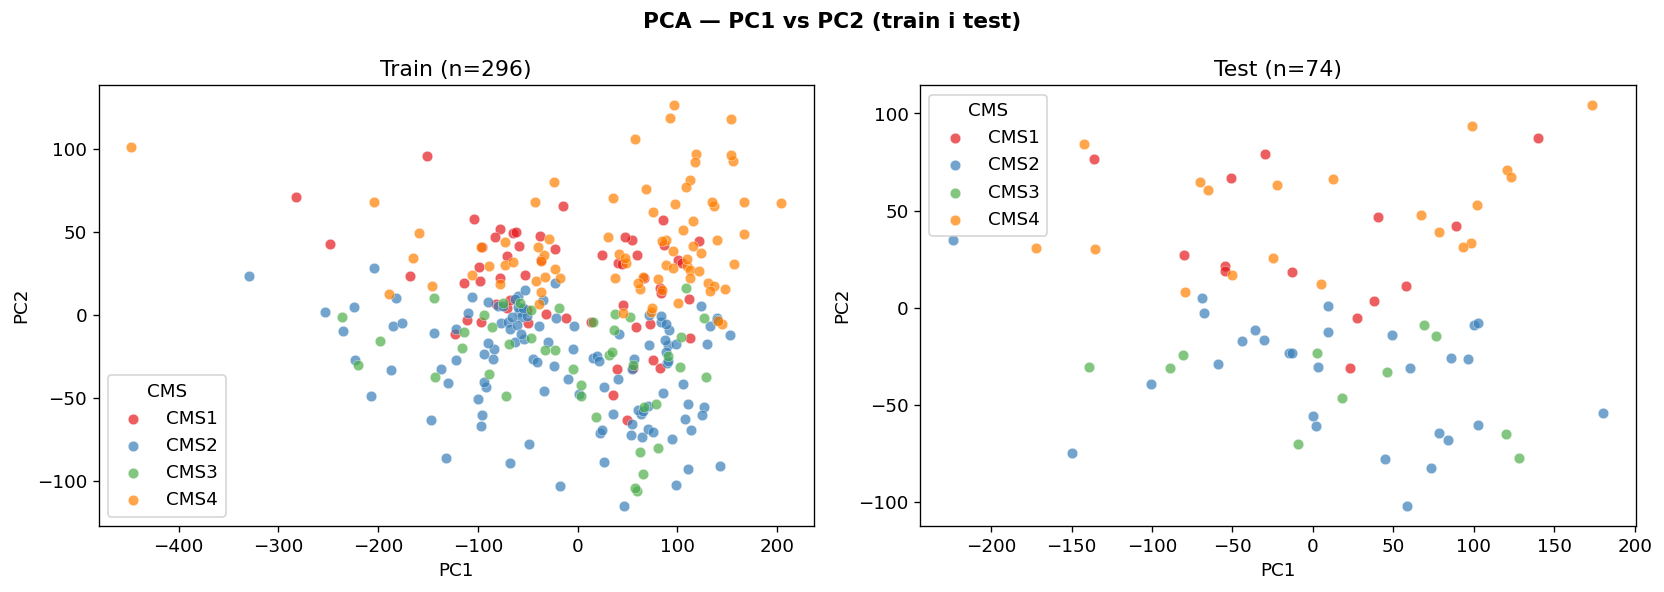

In [ ]:
# Scatter PC1 vs PC2 — train i test junts per comparar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (coords, labels, title) in zip(axes, [
    (pca_train, y_train, "Train (n=296)"),
    (pca_test,  y_test,  "Test (n=74)"),
]):
    for cms, colour in CMS_PALETTE.items():
        mask = labels == cms
        ax.scatter(coords.loc[mask, "PC1"], coords.loc[mask, "PC2"],
                   c=colour, label=cms, alpha=0.7, s=40,
                   edgecolors="white", linewidths=0.3)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend(title="CMS")

fig.suptitle("PCA — PC1 vs PC2 (train i test)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pca_scatter_train_test.png", dpi=150, bbox_inches="tight")
plt.show()

**Observació:** Si els subtipus CMS formen grups separats en el scatter plot,
significa que l'expressió gènica és un bon discriminador — bon senyal per als models.
Si els grups se superposen molt, la tasca serà més difícil.

Nota: el test hauria de mostrar la mateixa estructura que el train —
si no és així, pot indicar que el split no és representatiu.

## 6. Quanta variança explica cada component?

### El problema de les 15.625 dimensions

PCA ha calculat 50 components. Però no tots capturen la mateixa quantitat d'informació.
El **scree plot** (gràfic de colze) mostra:

- **Barres blaves:** percentatge de variança que captura cada component individualment.
  PC1 sempre és el més alt, PC2 el segon, etc.
- **Línia vermella:** variança acumulada. Quan arriba al 80% (línia discontínua),
  ja tenim prou components per representar la majoria de la informació del dataset.

### Per a informàtics: analogia amb compressió

És similar a la compressió d'imatges JPEG: els primers coeficients de la transformació
(els components principals) capturen el "gruix" de la imatge; els últims capturen
detalls fins i soroll. En RNA-seq, els primers components capturen la biologia;
els últims, soroll tècnic.

**Tipus de gràfic:** barres verticals + línia acumulada en dos eixos Y.
L'eix Y esquerre (blau) mostra la variança individual per component.
L'eix Y dret (vermell) mostra la variança acumulada.

**Què hauríem de veure:**
- PC1 dominant (>10-20%) → hi ha una font principal de variació (p.ex. separació CMS2 vs resta)
- Colze pronunciat als primers 5-15 components → la majoria de la informació biològica
  útil está en pocs components
- 80% de variança en 10-30 components → típic en RNA-seq ben preprocessat


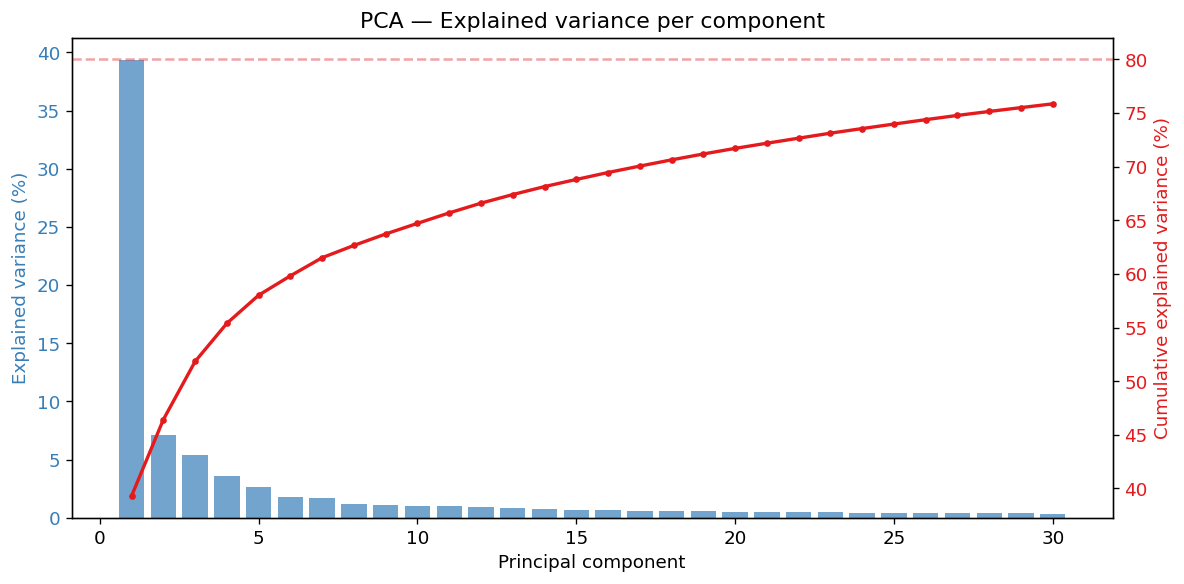

Components necessaris per al 80% de variança: 46
Variança dels 2 primers components: 46.4%
Variança dels 10 primers components: 64.7%


In [ ]:
fig = plot_explained_variance(
    pca, n_components=30,
    output_path=FIGURES_DIR / "pca_explained_variance.png"
)
plt.show()

# Quants components fan falta per arribar al 80%?
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
n80 = int(np.searchsorted(cumvar, 80)) + 1
print(f"Components necessaris per al 80% de variança: {n80}")
print(f"Variança dels 2 primers components: {cumvar[1]:.1f}%")
print(f"Variança dels 10 primers components: {cumvar[9]:.1f}%")

**Interpretació del scree plot:**

- **PC1 molt dominant** → hi ha una font de variació molt forta (pot ser biològica o tècnica).
- **Molts components necessaris per al 80%** → les dades estan distribuïdes en moltes dimensions.
  Típic en RNA-seq amb molts gens.
- **Colze pronunciat** → existeix un nombre "natural" de dimensions significatives.

## 7. Quins gens contribueixen més a la separació?

### Què és un loading?

Cada component principal (PC1, PC2...) és una **combinació lineal de tots els gens**:

```
PC1 = 0.023 × TSPAN6  +  (-0.041) × TNMD  +  0.018 × DPM1  + ...  (15.625 termes)
```

El coeficient de cada gen en aquesta suma s'anomena **loading**.
Un loading **gran en valor absolut** significa que aquell gen contribueix molt a
aquell component — és a dir, que les diferències d'expressió d'aquell gen
ajuden a separar les mostres en la direcció del component.

**Loading positiu (+):** mostres amb expressió alta d'aquest gen es mouen cap al
costat positiu de l'eix PC.

**Loading negatiu (−):** mostres amb expressió alta d'aquest gen es mouen cap al
costat negatiu.

### Per a informàtics: analogia amb feature importance

És conceptualment similar al `feature_importances_` d'un Random Forest:
indica quines variables (gens) expliquen més la variació observada en les dades.
La diferència és que PCA és no supervisat — no sap les etiquetes CMS.

### Tipus de gràfic: bar chart horitzontal

Cada barra és un gen. La longitud representa el loading (positiu o negatiu).
Els gens estan ordenats per valor absolut descendent: els més importants a dalt.

**Què hauríem de veure:**
Idealment, els gens amb loading alt en PC1 o PC2 correspondran a gens amb rol biològic
conegut als subtipus CMS (p.ex. gens del sistema immune per CMS1, gens mesenquimals
per CMS4). Això validaria que el PCA captura biologia real i no soroll tècnic.


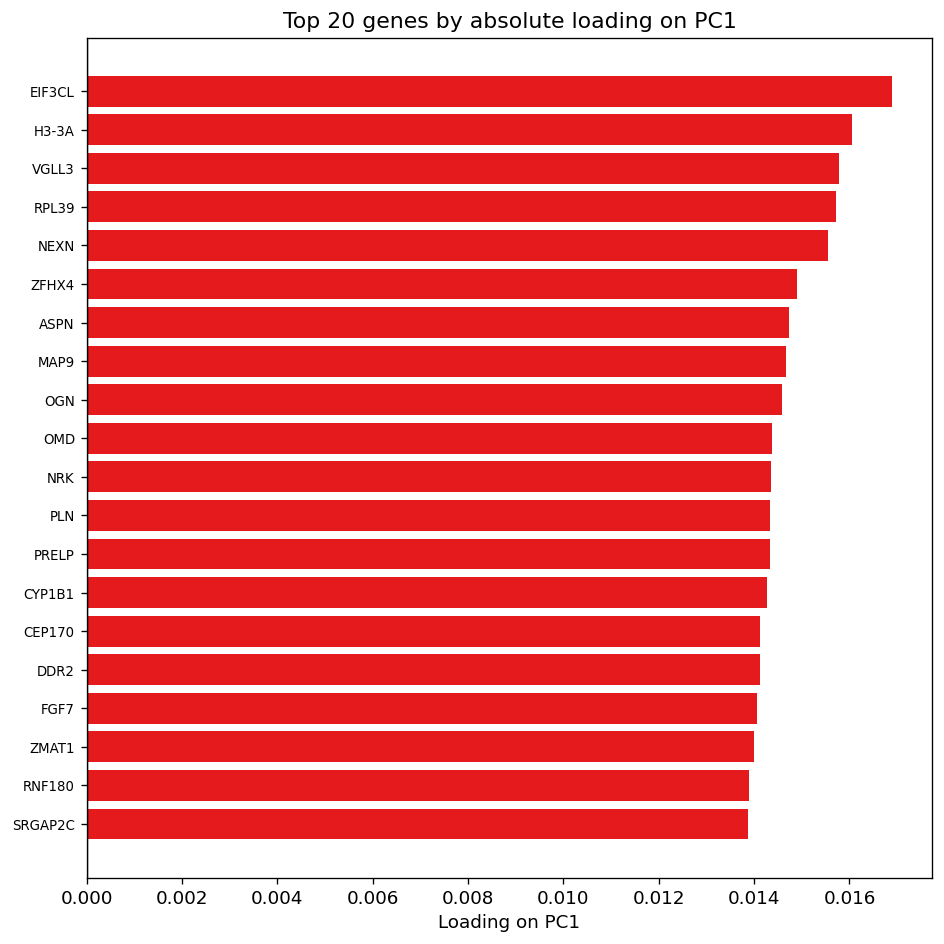

In [ ]:
# Top gens per PC1
fig = plot_top_genes(
    pca, gene_names, component=1, top_n=20,
    output_path=FIGURES_DIR / "pca_top_genes_pc1.png"
)
plt.show()

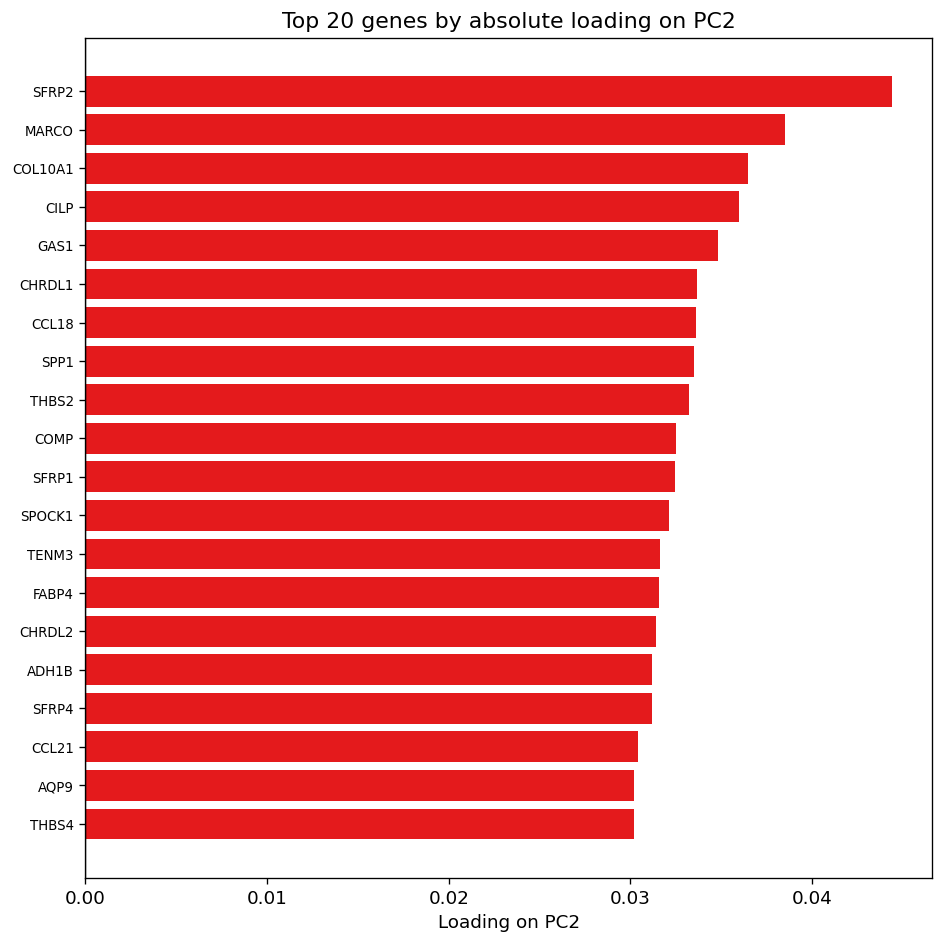

In [ ]:
# Top gens per PC2
fig = plot_top_genes(
    pca, gene_names, component=2, top_n=20,
    output_path=FIGURES_DIR / "pca_top_genes_pc2.png"
)
plt.show()

**Interpretació:** Les barres vermelles indiquen gens que contribueixen positivament al component
(mostres amb expressió alta d'aquest gen es mouen cap a la dreta en l'eix PC);
les blaves contribueixen negativament.

Si reconeixem gens relacionats amb les signatures CMS (p.ex. gens immunes a PC1
relacionats amb CMS1, o gens mesenquimals a PC4), és una validació biològica
que el preprocessament és correcte.

## 8. UMAP — Visualització no lineal

### PCA vs UMAP

| | PCA | UMAP |
|-|-----|------|
| Tipus | Lineal | No lineal |
| Interpetabilitat | Alta (components = combinació de gens) | Baixa (no s'interpreta directament) |
| Preservació de l'estructura | Global (variança) | Local (veïnats) |
| Velocitat | Molt ràpida | Lenta en datasets grans |
| Ús principal | Reducció + exploració | Visualització de clústers |

UMAP és millor per **visualitzar clústers** perquè preserva la proximitat entre punts
veïns. Si els subtipus CMS formen grups compactes en UMAP, la separació és robusta.

> **Nota:** UMAP requereix el paquet `umap-learn`. Si no el tens instal·lat,
> executa `pip install umap-learn` abans de continuar.

/home/mrivero/miniforge3/envs/tcga-coad-cms-ml-pipeline/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mrivero/miniforge3/envs/tcga-coad-cms-ml-pipeline/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


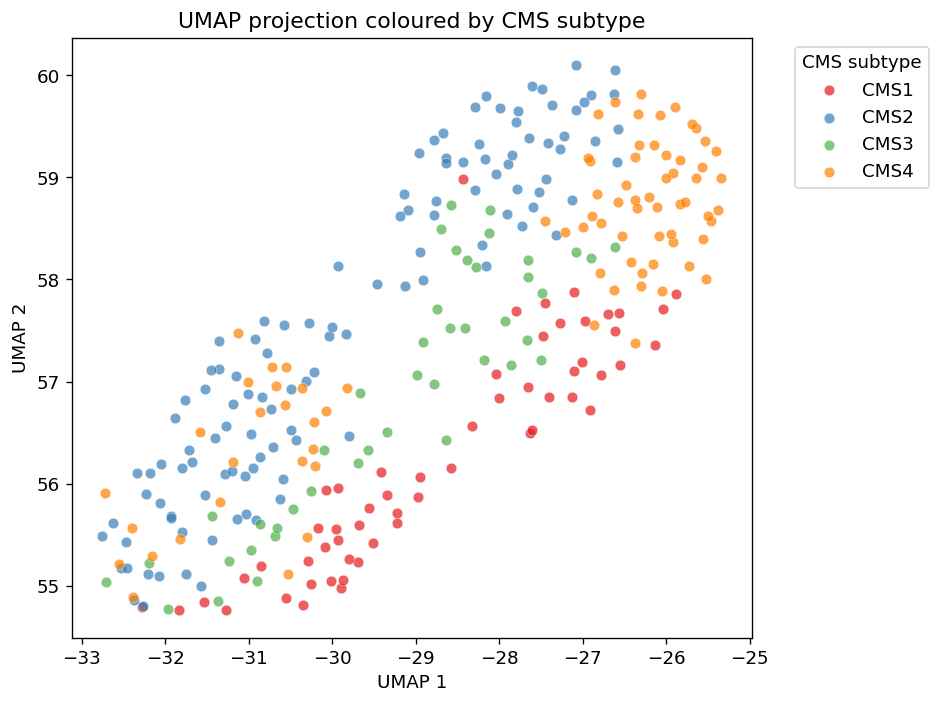

In [ ]:
# UMAP sobre les dades de train (pot trigar 1-2 minuts)
fig = plot_umap_scatter(
    X_train, y_train,
    n_neighbors=30,
    min_dist=0.3,
    random_state=42,
    output_path=FIGURES_DIR / "umap_scatter_train.png"
)
plt.show()

**Observació:** Si els grups UMAP coincideixen amb els de PCA, la separació
és consistent entre mètodes. Si UMAP mostra una separació millor que PCA,
pot ser que l'estructura sigui no lineal (PCA no la captura del tot).

## 9. Conclusions

Resumim les observacions d'aquesta exploració:

### Sobre el dataset
- **370 mostres** amb etiqueta CMS vàlida (296 train / 74 test).
- **15.625 gens** protein-coding, log2-transformats. Rang: [0, ~21].
- Les classes **no estan equilibrades**: CMS2 dominant (~39%), CMS3 minoritari (~15%).

### Sobre la separabilitat
- El scatter PCA PC1 vs PC2 ens diu si els subtipus CMS es poden separar linealment.
- El UMAP ens diu si hi ha estructura de clústers no lineal.

### Implicació per als models
- Si la separació és clara → els models haurien de funcionar bé.
- El desbalanceig de classes (CMS2 >> CMS3) pot afectar els models.
  Usarem **F1 macro** i **matriu de confusió** com a mètriques principals
  (no accuracy sola), per detectar si el model ignora les classes minoritàries.

---

Anem a l'etapa 4: **entrenament dels models** (`scripts/train.py`).